# 02 - Modelagem e Backtesting

**Objetivo:** comparar baselines e modelos por validação temporal (backtesting) e escolher o modelo pela métrica de decisão.

**Alvo:** receita diária (dor de negócio priorizada = previsibilidade de receita).

**Métricas:** MAE (R$, comunicável) e MASE (vs. Seasonal Naive, decisão) como primárias; RMSE e sMAPE como secundárias.

**Validação:** walk-forward / expanding window — nunca split aleatório em série temporal.

In [1]:
from coffee_forecast.config import load_config
from coffee_forecast.data.load import load_raw
from coffee_forecast.data.preprocess import prepare
from coffee_forecast.models.evaluate import run_backtest

cfg = load_config()
daily = prepare(load_raw(cfg, download=False), cfg)
daily[['revenue']].tail()

,revenue
date,
2025-03-19,623.56
2025-03-20,597.60
2025-03-21,636.80
2025-03-22,365.42
2025-03-23,204.76


## 1. Baselines — a régua

Antes de qualquer modelo sofisticado, estabelecemos referências simples. Nenhum modelo deve ir a produção sem superar o Seasonal Naive de forma consistente.

In [2]:
from coffee_forecast.models.baseline import get_baselines
for b in get_baselines(cfg.forecast.seasonal_period):
    print('-', b.name)

- naive
- seasonal_naive
- moving_average


## 2. Backtesting comparativo (baselines + SARIMA + Prophet + LightGBM)

Cada modelo é treinado e avaliado em múltiplas dobras temporais. As métricas são registradas no MLflow.

In [3]:
report = run_backtest(daily, cfg, target='revenue', use_mlflow=False)
summary = report.summary()
summary

Importing plotly failed. Interactive plots will not work.


16:51:32 - cmdstanpy - INFO - Chain [1] start processing


16:51:32 - cmdstanpy - INFO - Chain [1] done processing


16:51:32 - cmdstanpy - INFO - Chain [1] start processing


16:51:32 - cmdstanpy - INFO - Chain [1] done processing


...

16:51:33 - cmdstanpy - INFO - Chain [1] start processing


16:51:33 - cmdstanpy - INFO - Chain [1] done processing


16:51:33 - cmdstanpy - INFO - Chain [1] start processing


16:51:33 - cmdstanpy - INFO - Chain [1] done processing


,mae,mase,rmse,smape
model,,,,
lightgbm,123.047046,0.817628,163.946114,37.452828
sarima,146.462052,0.973117,176.262031,46.407340
seasonal_naive,148.927714,0.989850,177.007750,54.900179
moving_average,155.491633,1.034240,184.115301,49.022657
prophet,158.710832,1.054873,200.565905,46.340216
naive,230.227143,1.531954,267.464871,81.341283


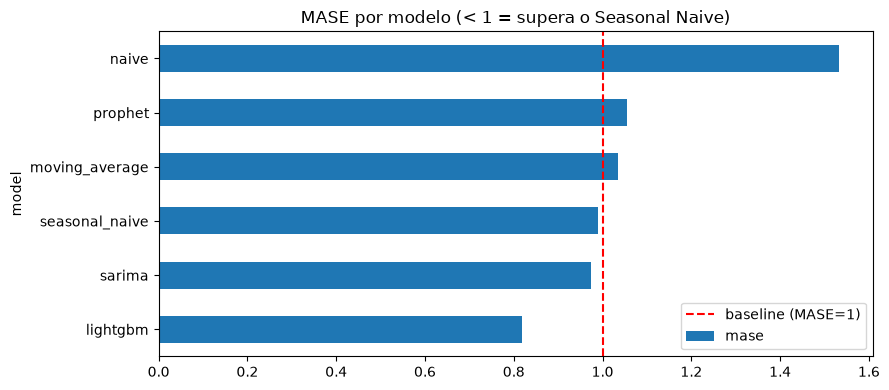

In [4]:
import matplotlib.pyplot as plt
summary['mase'].plot(kind='barh', figsize=(9,4), title='MASE por modelo (< 1 = supera o Seasonal Naive)')
plt.axvline(1.0, color='red', linestyle='--', label='baseline (MASE=1)')
plt.legend(); plt.tight_layout()

## 2.1 Walk-forward na prática: real vs. previsto (última dobra)

Para tornar a validação temporal tangível, isolamos a **última dobra** do backtesting: treinamos o LightGBM com todo o histórico até o início do teste e comparamos a previsão com o realizado. A linha pontilhada marca a fronteira treino/teste.

Observação honesta: o modelo acompanha bem a **direção** e o padrão semanal, mas tende a **suavizar os extremos** (conservador em picos e vales). Isso é esperado em série de baixo volume e reforça o valor da faixa de incerteza.

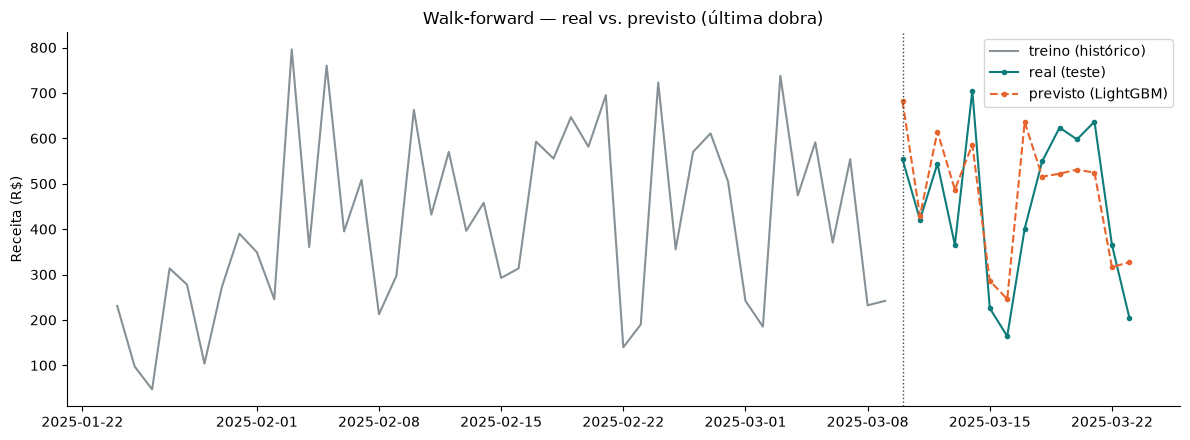

In [5]:
from coffee_forecast.models.evaluate import _make_splits
from coffee_forecast.models.train import LightGBMForecaster

y = daily['revenue'].astype(float)
splits = _make_splits(len(y), cfg.backtest.n_splits, cfg.backtest.test_size, cfg.backtest.min_train_size)
train_end, test_end = splits[-1]  # última dobra
y_train, y_test = y.iloc[:train_end], y.iloc[train_end:test_end]

m = LightGBMForecaster(lags=cfg.features.lags, rolling_windows=cfg.features.rolling_windows).fit(y_train)
y_pred = m.predict(len(y_test))

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(y_train.tail(45).index, y_train.tail(45).to_numpy(), color='#37474F', alpha=0.6, label='treino (histórico)')
ax.plot(y_test.index, y_test.to_numpy(), color='#0E7C7B', marker='o', markersize=3, label='real (teste)')
ax.plot(y_test.index, y_pred, color='#E7642C', marker='o', markersize=3, linestyle='--', label='previsto (LightGBM)')
ax.axvline(y_test.index[0], color='#37474F', linestyle=':', linewidth=1)
ax.set_title('Walk-forward — real vs. previsto (última dobra)'); ax.set_ylabel('Receita (R$)'); ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()

## 3. Modelo vencedor: treino final + previsão futura com intervalo

Melhor modelo (menor MASE): lightgbm


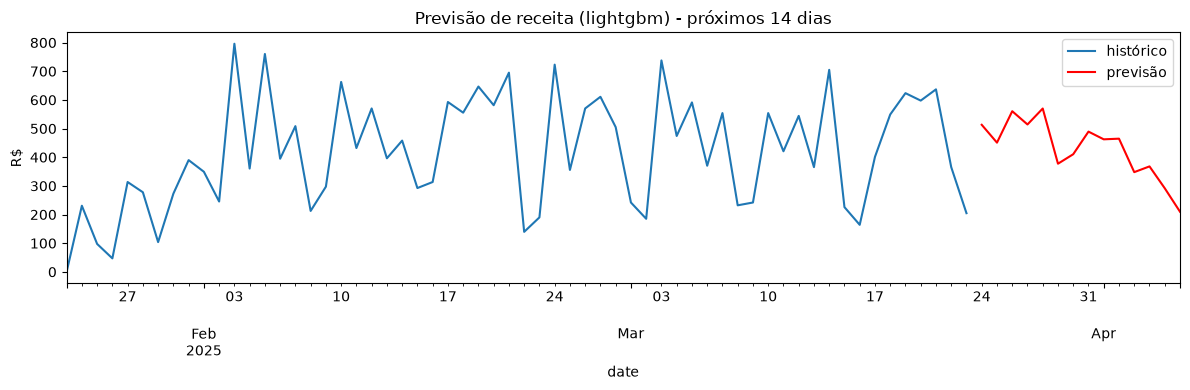

In [6]:
import pandas as pd
from coffee_forecast.models.train import build_models

best = summary.index[0]
print('Melhor modelo (menor MASE):', best)

y = daily['revenue'].astype(float)
h = cfg.forecast.horizon
model = build_models(cfg)[best].fit(y)
yhat = model.predict(h)
idx = pd.date_range(y.index[-1] + pd.Timedelta(days=1), periods=h)
fc = pd.Series(yhat, index=idx, name='forecast')

ax = y.tail(60).plot(figsize=(12,4), label='histórico')
fc.plot(ax=ax, color='red', label='previsão')
ax.set_title(f'Previsão de receita ({best}) - próximos {h} dias'); ax.set_ylabel('R$'); ax.legend()
plt.tight_layout()

## 4. Interpretabilidade (LightGBM)

Se o vencedor for o LightGBM, a importância das features mostra o que dirige a previsão (comunicação + confiança).

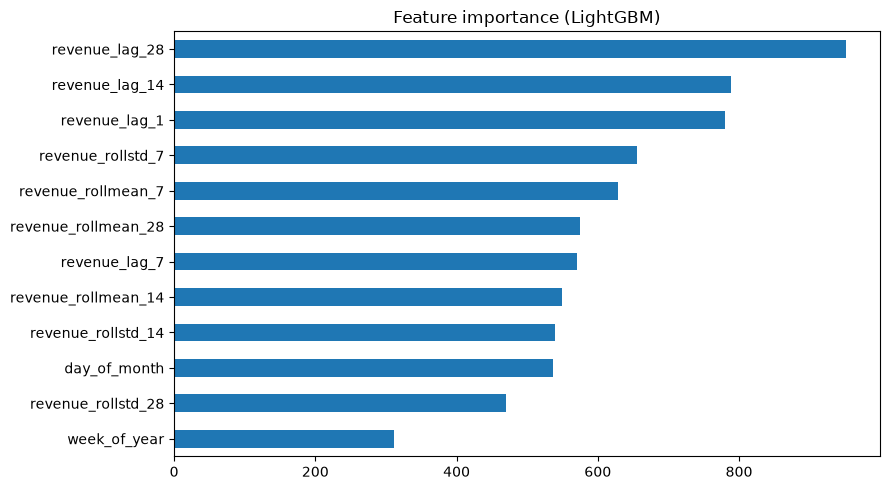

In [7]:
if best == 'lightgbm':
    imp = model.feature_importance().head(12)
    imp.sort_values().plot(kind='barh', figsize=(9,5), title='Feature importance (LightGBM)')
    plt.tight_layout()
else:
    print('Modelo vencedor não é LightGBM; pular esta célula.')

## Conclusões da modelagem

- **LightGBM** foi o melhor (MASE ~0,82: erro ~18% menor que o baseline sazonal).
- SARIMA empata tecnicamente com o Seasonal Naive; o Naive puro é o piso.
- **Aprendizado:** modelo mais complexo não é garantia de melhor resultado (Prophet ficou perto do baseline). Por isso comparamos contra a régua.
- Ver rastreamento dos experimentos no MLflow: `mlflow ui --backend-store-uri sqlite:///mlflow.db`.